# Exploratory Data Analysis

Perform EDA covering:
- Data Summarization - descriptive statistics for numerical features (TotalPremium, TotalClaims, etc.), and a review of dtypes to confirm categorical, date, and numerical columns are correctly typed.
- Data Quality Assessment - check for missing values and document handling strategy.
- Univariate Analysis - histograms for numerical columns and bar charts for categorical columns.
- Bivariate / Multivariate Analysis - relationships between TotalPremium and TotalClaims as a function of ZipCode, using scatter plots and correlation matrices.
- Geographic Trends - compare cover type, premium, and auto make across provinces.
- Outlier Detection - use box plots on key numerical features.

In [16]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: /home/melki/Desktop/tenx/project/insurance-risk-analytics


In [17]:
from src.data_loader import (
    load_insurance_data, 
    load_cleaned_data,
)
from src.eda_utils import (
    summarize_data, 
    check_data_quality, 
    plot_numerical_distributions,
    plot_categorical_distributions, 
    plot_premium_vs_claims, 
    plot_correlation_matrix, 
    analyze_geographic_trends, 
    analyze_vehicle_makes, 
    save_cleaned_data,
    detect_outliers, 
    create_derived_metrics, 
    handle_missing_values,
    get_numerical_columns,
    get_categorical_columns,
    check_missing_values,
)

In [ ]:
# Load the data
df = load_insurance_data(file_path="../data/insurance_data.txt")
df.head()

INFO:src.data_loader:Loading data from: ../data/insurance_data.txt


### Data Summarization

In [ ]:
summarize_data(df)

DATA SUMMARIZATION
Dataset Shape: 1,000,098 rows × 52 columns

DATA TYPES:
str        36
float64    11
int64       4
bool        1
Name: count, dtype: int64


NUMERICAL COLUMNS (15):
['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']

Descriptive Statistics:
       UnderwrittenCoverID    PolicyID  PostalCode       mmcode  \
count           1000098.00  1000098.00  1000098.00    999546.00   
mean             104817.55     7956.68     3020.60  54877704.02   
std               63293.71     5290.04     2649.85  13603805.34   
min                   1.00       14.00        1.00   4041200.00   
25%               55143.00     4500.00      827.00  60056925.00   
50%               94083.00     7071.00     2000.00  60058415.00   
75%              139190.00    11077.00     4180.00  60058418

### Data Quality Assessment

In [ ]:
check_data_quality(df)

DATA QUALITY ASSESSMENT


Parsed 0         2015-03-01
1         2015-05-01
2         2015-07-01
3         2015-05-01
4         2015-07-01
             ...    
1000093   2015-04-01
1000094   2015-06-01
1000095   2015-08-01
1000096   2014-07-01
1000097   2015-02-01
Name: TransactionMonth, Length: 1000098, dtype: datetime64[us] as datetime.
Top 15 Columns with Missing Values:
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
Citizenship                     895210      89.51
CustomValueEstimate             779642      77.96
Rebuilt                         641901      64.18
Converted                       641901      64.18
WrittenOff                      641901      64.18
NewVehicle                      153295      15.33
Bank                            145961      14.59
AccountType                      40232       4.02
Gender                            9536       0.95
MaritalStatus                     8259       0.83


,Missing Count,Missing %
NumberOfVehiclesInFleet,1000098,100.00
CrossBorder,999400,99.93
Citizenship,895210,89.51
CustomValueEstimate,779642,77.96
Rebuilt,641901,64.18
Converted,641901,64.18
WrittenOff,641901,64.18
NewVehicle,153295,15.33
Bank,145961,14.59
AccountType,40232,4.02


## Data Quality Assessment & Missing Values Handling Strategy

### 1. Missing Values Overview

During the initial data quality check, several columns showed significant missing values. Below is the summary before cleaning:

| Column                        | Missing Count | Missing %   |
|-------------------------------|---------------|-------------|
| NumberOfVehiclesInFleet       | 1,000,098     | 100.00%     |
| CrossBorder                   | 999,400       | 99.93%      |
| Citizenship                   | 895,210       | 89.51%      |
| CustomValueEstimate           | 779,642       | 77.96%      |
| Rebuilt / WrittenOff / Converted | 641,901    | 64.18%      |
| LossRatio                     | 381,634       | 38.16%      |
| NewVehicle                    | 153,295       | 15.33%      |
| Bank                          | 145,961       | 14.59%      |
| AccountType                   | 40,232        | 4.02%       |
| Gender                        | 9,536         | 0.95%       |
| MaritalStatus                 | 8,259         | 0.83%       |
| Vehicle-related fields        | ~552          | 0.06%       |

---

### 2. Missing Values Handling Strategy

The following strategy was applied to ensure data quality while preserving as much information as possible:

#### **Decision Rules:**
- **Drop Column**: If missing percentage > **60%**
- **Drop Rows**: If missing percentage ≤ **2%** (to maintain data cleanliness)
- **Impute (Fill)**: If missing percentage is between **2% and 60%**

#### **Actions Taken:**

1. **Columns Dropped** (High missing rate):
   - `NumberOfVehiclesInFleet`, `CrossBorder`, `Citizenship`, `CustomValueEstimate`
   - `Rebuilt`, `WrittenOff`, `Converted`

2. **Rows Dropped**:
   - Applied on columns with very low missing rates (≤ 2%)

3. **Imputation Method**:
   - **Categorical columns** → Filled with **Mode** (most frequent value)
   - **Numerical columns** → Filled with **Median**

---

### 3. Rationale

- High missing rate columns (>60%) were dropped because they provide little analytical value and could introduce noise.
- Row deletion was kept minimal to avoid significant data loss, given the large size of the dataset.
- Mode imputation for categorical variables and median for numerical variables were chosen as they are robust to outliers common in insurance data.
- This approach balances **data integrity** with **maximum data retention**, which is critical for reliable risk modeling and statistical testing.

---

### 4. Post-Cleaning Summary

- Final dataset shape: **(999_544, 40)**
- Total columns dropped: **7**
- Remaining missing values: **0**

This cleaning process ensures that subsequent analysis (EDA, hypothesis testing, and modeling) is performed on high-quality, consistent data.

In [ ]:
# remove missing values before plotting distributions
df = handle_missing_values(df)

AUTOMATIC MISSING VALUE HANDLING
🗑️ Dropping 12 columns (> 60.0% missing)

📉 Checking columns for row dropping (threshold ≤ 2.0%)...
   → Dropped 552 rows from 'mmcode' (0.06%)
   → Dropped 2 rows from 'CapitalOutstanding' (0.00%)

🔧 Filling remaining missing values...

✅ Final Shape: 999,544 rows × 40 columns


In [ ]:
# Add metrics
df = create_derived_metrics(df)

In [ ]:
save_cleaned_data(df)

Cleaned data saved to ../data/cleaned_insurance_data.csv


In [ ]:
df_clean = load_cleaned_data(file_path="../data/processed/cleaned_insurance_data.csv")
df_clean.head()

INFO:src.data_loader:Loading cleaned data from: ../data/processed/cleaned_insurance_data.csv
/home/melki/Desktop/tenx/project/insurance-risk-analytics/src/data_loader.py:86: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=parse_dates)
INFO:src.data_loader:✅ Cleaned data loaded successfully! Shape: (999544, 42)
INFO:src.data_loader:Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'LegalType', 'Title', 'Language', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product',

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,LegalType,Title,Language,Country,Province,PostalCode,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01,True,Close Corporation,Mr,English,South Africa,Gauteng,1459,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01,True,Close Corporation,Mr,English,South Africa,Gauteng,1459,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145249,12827,2015-07-01,True,Close Corporation,Mr,English,South Africa,Gauteng,1459,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0.000000
3,145255,12827,2015-05-01,True,Close Corporation,Mr,English,South Africa,Gauteng,1459,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
4,145255,12827,2015-07-01,True,Close Corporation,Mr,English,South Africa,Gauteng,1459,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0.000000


In [ ]:
check_missing_values(df_clean)

MISSING VALUE CHECK
Top 15 Columns with Missing Values:
                          Missing Count  Missing %
LossRatio                        381302      38.15
UnderwrittenCoverID                   0       0.00
CoverCategory                         0       0.00
VehicleIntroDate                      0       0.00
AlarmImmobiliser                      0       0.00
TrackingDevice                        0       0.00
CapitalOutstanding                    0       0.00
SumInsured                            0       0.00
TermFrequency                         0       0.00
CalculatedPremiumPerTerm              0       0.00
ExcessSelected                        0       0.00
CoverType                             0       0.00
PolicyID                              0       0.00
CoverGroup                            0       0.00
Section                               0       0.00


,Missing Count,Missing %
LossRatio,381302,38.15
UnderwrittenCoverID,0,0.00
CoverCategory,0,0.00
VehicleIntroDate,0,0.00
AlarmImmobiliser,0,0.00
TrackingDevice,0,0.00
CapitalOutstanding,0,0.00
SumInsured,0,0.00
TermFrequency,0,0.00
CalculatedPremiumPerTerm,0,0.00


### Univariate Analysis

ValueError: num must be an integer with 1 <= num <= 6, not 7

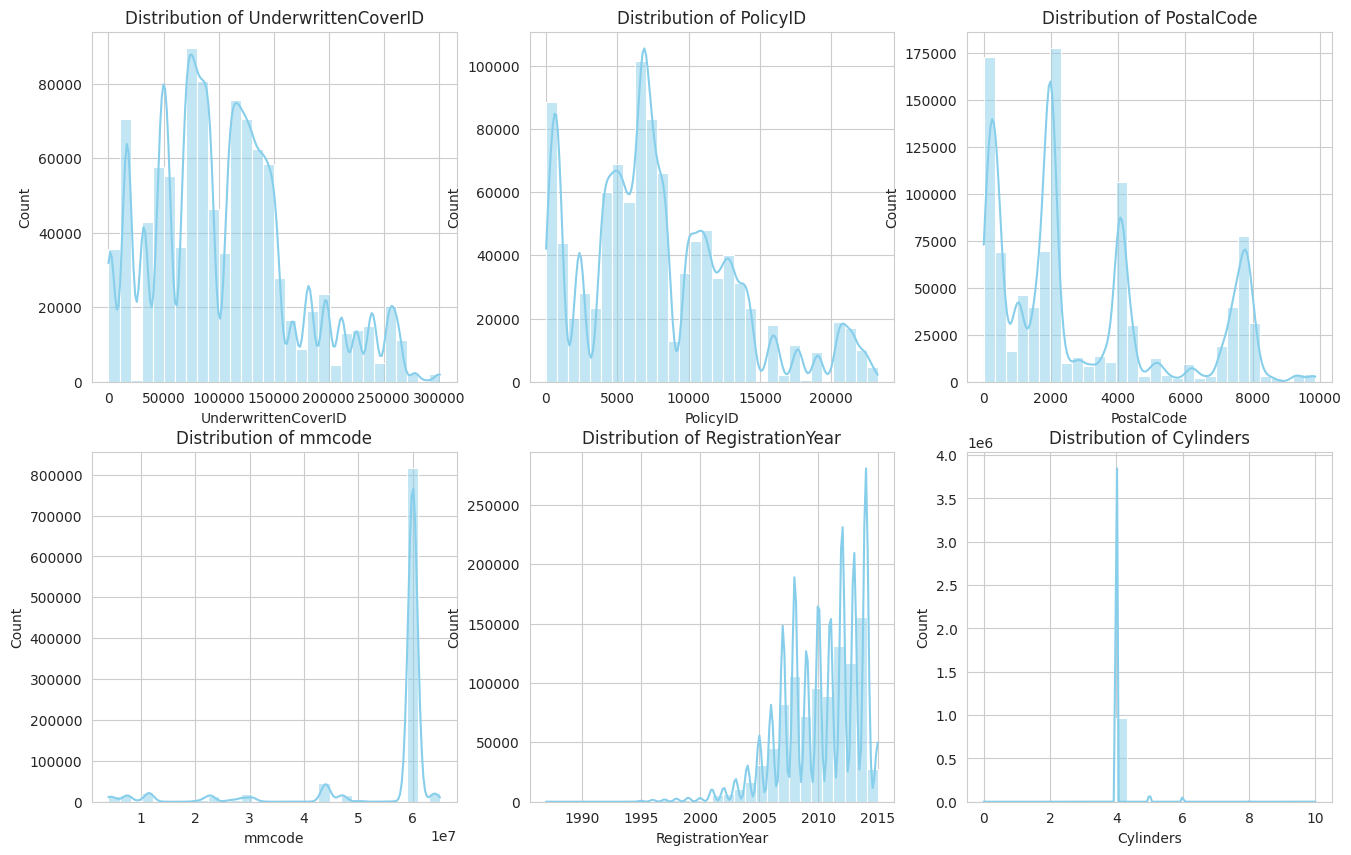

In [ ]:
# histograms for numerical columns
numerical_cols = get_numerical_columns(df)
plot_numerical_distributions(df, numerical_cols)

In [ ]:
# bar charts for categorical columns
categorical_cols = get_categorical_columns(df)
plot_categorical_distributions(df, categorical_cols)

### Bivariate / Multivariate Analysis

In [ ]:
plot_premium_vs_claims(df)

In [ ]:
plot_correlation_matrix(df)

### Geographic Trends

In [ ]:
analyze_geographic_trends(df)

In [ ]:
analyze_vehicle_makes(df)

### Outlier Detection

In [ ]:
detect_outliers(df)